# SmartTicket — Full ML Pipeline
**Weeks 4, 6 & 8 Deliverables**

This notebook covers the complete SmartTicket pipeline end-to-end:

- **Week 4** — Data ingestion from SQLite, text/numeric/categorical preprocessing, feature engineering, and two feature selection strategies (greedy forward heuristic + genetic algorithm)
- **Week 6** — Voting ensemble (hard, soft, weighted soft) and **stacking ensemble** (meta-learner) combining KNN, Decision Tree, Random Forest, Logistic Regression, and SVM
- **Week 8** — Logic-based explainability layer: symbolic rules that integrate with ML predictions, produce human-readable reasoning traces, and optionally override ML decisions when high-confidence rules disagree

---
## Section 1 — Imports & Setup

In [ ]:
import sqlite3
import os
import re
import random
import ssl
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack, csr_matrix

from voting_classifier import VotingEnsemble
from logic_explainer import TicketExplainer, print_rule_catalogue

import nltk
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

np.random.seed(42)
random.seed(42)

print("=" * 60)
print("  SmartTicket — Full ML Pipeline (Weeks 4, 6, 8)")
print("=" * 60)

---
## Section 2 — Data Ingestion from SQLite

We join the three normalized tables (`tickets`, `customer_metrics`, `ticket_metadata`) into a single DataFrame. The data was intentionally generated with noise: missing values, inconsistent casing, duplicates, outliers, and noisy text.

In [2]:
print("\n[Step 1] Loading data from SQLite database...")

db_path = os.path.join("..", "database", "smartticket.db")
conn = sqlite3.connect(db_path)

query = """
SELECT
    t.ticket_id, t.ticket_text, t.channel, t.product_category,
    t.region, t.department, t.priority,
    c.account_age_days, c.total_orders, c.total_spent,
    c.returns_count, c.avg_order_value, c.days_since_last_order,
    c.loyalty_tier, c.previous_tickets, c.avg_response_satisfaction,
    m.response_time_hours, m.num_attachments, m.num_replies,
    m.escalated, m.reopened, m.sentiment_score,
    m.word_count_raw, m.has_order_number
FROM tickets t
LEFT JOIN customer_metrics c ON t.ticket_id = c.ticket_id
LEFT JOIN ticket_metadata m ON t.ticket_id = m.ticket_id
"""

df = pd.read_sql_query(query, conn)
conn.close()

print(f"Loaded {len(df)} records")
print(f"Columns: {len(df.columns)}")
print(f"\nSample data:")
df.head()


[Step 1] Loading data from SQLite database...
Loaded 2687 records
Columns: 24

Sample data:


,ticket_id,ticket_text,channel,product_category,region,department,priority,account_age_days,total_orders,total_spent,...,previous_tickets,avg_response_satisfaction,response_time_hours,num_attachments,num_replies,escalated,reopened,sentiment_score,word_count_raw,has_order_number
0,TKT-000001,"I'm a first time buyer, wondering about your w...",email,software,NORTH_AMERICA,general,low,662.0,13.0,700.87,...,0.0,4.5,11.0,2.0,3.0,1.0,0.0,0.96,18.0,0.0
1,TKT-000002,I want to return Bluetooth Speaker from order ...,social_media,home,south_america,returns,low,351.0,35.0,2418.81,...,0.0,2.2,8.9,0.0,1.0,0.0,0.0,0.42,18.0,1.0
2,TKT-000003,Software license key LK-JV6OH9SDBDW2PCN9 isn't...,email,software,north_america,technical,high,146.0,3.0,116.44,...,0.0,2.6,10.8,4.0,0.0,0.0,0.0,0.22,16.0,0.0
3,TKT-000004,I was charged twice for order #897549. The dup...,chat,food,south_america,billing,high,552.0,1.0,43.77,...,4.0,2.2,-6.0,1.0,3.0,1.0,0.0,-0.12,23.0,1.0
4,TKT-000005,My account shows the wrong name... It says Ale...,Social_media,food,middle_east,account,low,398.0,0.0,0.00,...,1.0,3.1,9.5,2.0,0.0,0.0,0.0,0.94,19.0,0.0


In [3]:
print("Missing values:")
missing_report = df.isna().sum()
print(missing_report[missing_report > 0])
print(f"\nDepartment distribution:")
print(df["department"].value_counts())
print(f"\nPriority distribution:")
print(df["priority"].value_counts())

Missing values:
ticket_text                  130
channel                       92
product_category              62
account_age_days              92
total_orders                  85
total_spent                   64
returns_count                 63
avg_order_value               83
days_since_last_order         89
previous_tickets              88
avg_response_satisfaction     71
response_time_hours           90
num_attachments               87
num_replies                   90
escalated                     73
reopened                      95
sentiment_score               73
word_count_raw                84
has_order_number              72
dtype: int64

Department distribution:
department
technical    500
returns      457
billing      450
account      449
general      431
shipping     400
Name: count, dtype: int64

Priority distribution:
priority
medium    1017
low        641
high       564
urgent     465
Name: count, dtype: int64


In [4]:
# Remove duplicates
before = len(df)
df = df.drop_duplicates(subset=["ticket_id"], keep="first")
print(f"Removed {before - len(df)} duplicate tickets")
print(f"Records after dedup: {len(df)}")

Removed 187 duplicate tickets
Records after dedup: 2500


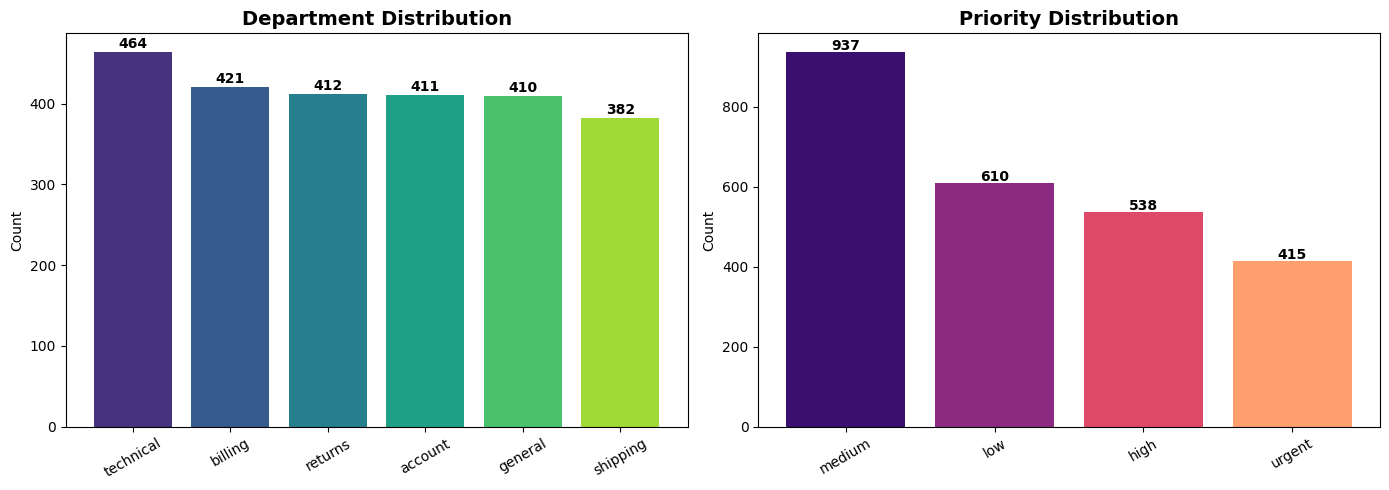

Saved class_distribution.png


In [5]:
# Class distribution chart
os.makedirs(os.path.join("..", "outputs"), exist_ok=True)
output_dir = os.path.join("..", "outputs")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_counts = df["department"].value_counts()
axes[0].bar(dept_counts.index, dept_counts.values, color=sns.color_palette("viridis", len(dept_counts)))
axes[0].set_title("Department Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(dept_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold", fontsize=10)

prio_counts = df["priority"].value_counts()
axes[1].bar(prio_counts.index, prio_counts.values, color=sns.color_palette("magma", len(prio_counts)))
axes[1].set_title("Priority Distribution", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(prio_counts.values):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "class_distribution.png"), dpi=150)
plt.show()
print("Saved class_distribution.png")

---
## Section 3 — Text Preprocessing Pipeline

The raw ticket text contains URLs, HTML fragments, email addresses, mixed casing, extra punctuation, and other noise. We clean the text in stages:

1. **Fill missing** — replace NULL texts with a placeholder
2. **Clean** — lowercase, strip URLs/HTML/emails/order numbers, keep only letters
3. **Stopwords** — remove common English stopwords (the, is, and, ...)
4. **Lemmatize** — reduce words to base form ("running" → "run")
5. **Engineer** — extract word_count, char_count, avg_word_len, sentence_count

In [6]:
# 3.1 Handle missing text
print("[Step 2] Preprocessing text data...")
missing = df["ticket_text"].isna().sum()
print(f"Missing ticket_text: {missing}")
df["ticket_text"] = df["ticket_text"].fillna("no description provided")

[Step 2] Preprocessing text data...
Missing ticket_text: 119


In [7]:
# 3.2 Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)             # URLs
    text = re.sub(r"\S+@\S+", "", text)              # emails
    text = re.sub(r"&\w+;", "", text)                # HTML entities
    text = re.sub(r"<[^>]+>", "", text)              # HTML tags
    text = re.sub(r"#\d+", "", text)                 # order numbers like #12345
    text = re.sub(r"\b\d+\.\d+\.\d+\.\d+\b", "", text)  # IP addresses
    text = re.sub(r"[^a-z\s]", "", text)             # non-alpha
    text = re.sub(r"\s+", " ", text).strip()         # normalize whitespace
    return text

df["clean_text"] = df["ticket_text"].apply(clean_text)

print("Text cleaning — before vs after:")
for i in range(5):
    print(f"  BEFORE: {str(df['ticket_text'].iloc[i])[:80]}...")
    print(f"  AFTER : {df['clean_text'].iloc[i][:80]}...")
    print()

Text cleaning — before vs after:
  BEFORE: I'm a first time buyer, wondering about your warranty policy for USB-C Hub. How ...
  AFTER : im a first time buyer wondering about your warranty policy for usbc hub how long...

  BEFORE: I want to return Bluetooth Speaker from order #793384. Bought it 10 days ago. Re...
  AFTER : i want to return bluetooth speaker from order bought it days ago reason not as d...

  BEFORE: Software license key LK-JV6OH9SDBDW2PCN9 isn't activating. Says 'already in use'...
  AFTER : software license key lkjvohsdbdwpcn isnt activating says already in use but i on...

  BEFORE: I was charged twice for order #897549. The duplicate charge of $271.02 appeared ...
  AFTER : i was charged twice for order the duplicate charge of appeared on please refund ...

  BEFORE: My account shows the wrong name... It says Alex but my name is Michael. Please f...
  AFTER : my account shows the wrong name it says alex but my name is michael please fix t...



In [8]:
# 3.3 Remove stopwords
stop_words = set(stopwords.words("english"))
df["clean_text"] = df["clean_text"].apply(
    lambda x: " ".join([w for w in x.split() if w not in stop_words])
)

print("After stopword removal (5 samples):")
for i in range(5):
    print(f"  {df['clean_text'].iloc[i][:90]}")

After stopword removal (5 samples):
  im first time buyer wondering warranty policy usbc hub long cover
  want return bluetooth speaker order bought days ago reason described
  software license key lkjvohsdbdwpcn isnt activating says already use one device
  charged twice order duplicate charge appeared please refund asap thank
  account shows wrong name says alex name michael please fix see


In [9]:
# 3.4 Lemmatization
lemmatizer = WordNetLemmatizer()
df["clean_text"] = df["clean_text"].apply(
    lambda x: " ".join([lemmatizer.lemmatize(w) for w in x.split()])
)

print("After lemmatization (5 samples):")
for i in range(5):
    print(f"  {df['clean_text'].iloc[i][:90]}")

After lemmatization (5 samples):
  im first time buyer wondering warranty policy usbc hub long cover
  want return bluetooth speaker order bought day ago reason described
  software license key lkjvohsdbdwpcn isnt activating say already use one device
  charged twice order duplicate charge appeared please refund asap thank
  account show wrong name say alex name michael please fix see


In [10]:
# 3.5 Text feature engineering
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))
df["char_count"] = df["clean_text"].apply(lambda x: len(x))
df["avg_word_len"] = df.apply(
    lambda x: x["char_count"] / x["word_count"] if x["word_count"] > 0 else 0, axis=1
)
df["sentence_count"] = df["ticket_text"].apply(
    lambda x: str(x).count(".") + str(x).count("!") + str(x).count("?") + 1
)

print("Text-derived features — word_count stats:")
print(df["word_count"].describe())

Text-derived features — word_count stats:
count    2500.000000
mean       10.111600
std         3.136221
min         2.000000
25%         8.000000
50%        11.000000
75%        12.000000
max        19.000000
Name: word_count, dtype: float64


In [11]:
# 3.6 Remove text outliers
q_low = df["word_count"].quantile(0.01)
q_high = df["word_count"].quantile(0.99)
before = len(df)
df = df[(df["word_count"] >= q_low) & (df["word_count"] <= q_high)]
print(f"Removed {before - len(df)} text outliers (word_count outside [{q_low}, {q_high}])")
print(f"Records remaining: {len(df)}")

Removed 24 text outliers (word_count outside [2.0, 16.0])
Records remaining: 2476


---
## Section 4 — Numeric Preprocessing

Numeric columns contain:
- **Missing values** (~3% randomly injected NaNs) — filled with the column median
- **Outliers** (e.g., `total_spent = 999999`, negative `response_time_hours`, `satisfaction > 5`) — clipped to valid ranges
- **Derived features** — ratios and rates computed from raw columns

In [12]:
print("[Step 3] Preprocessing numeric data...")

numeric_cols = [
    "account_age_days", "total_orders", "total_spent", "returns_count",
    "avg_order_value", "days_since_last_order", "previous_tickets",
    "avg_response_satisfaction", "response_time_hours", "num_attachments",
    "num_replies", "escalated", "reopened", "sentiment_score",
    "word_count_raw", "has_order_number",
]

# 4.1 Handle missing values
print("Missing values before fill:")
missing_before = df[numeric_cols].isna().sum()
print(missing_before[missing_before > 0])

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

print("Missing values after fill: 0")

[Step 3] Preprocessing numeric data...
Missing values before fill:
account_age_days             83
total_orders                 70
total_spent                  63
returns_count                59
avg_order_value              80
days_since_last_order        75
previous_tickets             83
avg_response_satisfaction    68
response_time_hours          83
num_attachments              86
num_replies                  86
escalated                    73
reopened                     80
sentiment_score              69
word_count_raw               80
has_order_number             68
dtype: int64
Missing values after fill: 0


In [13]:
# 4.2 Clip outliers
df["total_spent"] = df["total_spent"].clip(0, 50000)
df["account_age_days"] = df["account_age_days"].clip(0, 3650)
df["response_time_hours"] = df["response_time_hours"].clip(0, 168)
df["avg_response_satisfaction"] = df["avg_response_satisfaction"].clip(1, 5)
print("Outliers clipped to valid ranges")

Outliers clipped to valid ranges


In [14]:
# 4.3 Derived features
df["spend_per_order"] = df["total_spent"] / (df["total_orders"] + 1)
df["return_rate"] = df["returns_count"] / (df["total_orders"] + 1)
df["ticket_rate"] = df["previous_tickets"] / (df["account_age_days"] / 30 + 1)
df["order_recency_score"] = 1 / (df["days_since_last_order"] + 1)

derived_cols = ["spend_per_order", "return_rate", "ticket_rate", "order_recency_score"]
print(f"Engineered {len(derived_cols)} derived features: {derived_cols}")

Engineered 4 derived features: ['spend_per_order', 'return_rate', 'ticket_rate', 'order_recency_score']


---
## Section 5 — Categorical Encoding

Categorical columns (`channel`, `product_category`, `region`, `loyalty_tier`) have inconsistent casing ("Email" vs "email" vs "EMAIL"). We standardize to lowercase, fill unknowns, and one-hot encode.

In [15]:
print("[Step 4] Encoding categorical features...")

cat_cols = ["channel", "product_category", "region", "loyalty_tier"]

# 5.1 Standardize casing
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].replace({"nan": "unknown", "none": "unknown", "": "unknown"})

print("Unique values after standardization:")
for col in cat_cols:
    print(f"  {col}: {sorted(df[col].unique())}")

[Step 4] Encoding categorical features...
Unique values after standardization:
  channel: ['chat', 'email', 'phone', 'social_media', 'unknown', 'web_form']
  product_category: ['clothing', 'electronics', 'food', 'home', 'software', 'subscription', 'unknown']
  region: ['africa', 'asia', 'europe', 'middle_east', 'north_america', 'south_america']
  loyalty_tier: ['bronze', 'gold', 'platinum', 'silver']


In [16]:
# 5.2 One-hot encode
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=float)
ohe_cols = [c for c in df.columns if any(c.startswith(cat + "_") for cat in cat_cols)]
print(f"One-hot encoded: {len(ohe_cols)} columns")

One-hot encoded: 19 columns


In [17]:
# 5.3 Encode targets
le_dept = LabelEncoder()
le_prio = LabelEncoder()
df["department_encoded"] = le_dept.fit_transform(df["department"])
df["priority_encoded"] = le_prio.fit_transform(df["priority"])
print(f"Department classes: {list(le_dept.classes_)}")
print(f"Priority classes: {list(le_prio.classes_)}")

Department classes: ['account', 'billing', 'general', 'returns', 'shipping', 'technical']
Priority classes: ['high', 'low', 'medium', 'urgent']


---
## Section 6 — Build Feature Matrix

We combine three feature groups into one sparse matrix:
- **TF-IDF** (500 features from cleaned text)
- **Scaled numeric** (16 raw + 4 derived + 4 text-derived = 24 features)
- **One-hot encoded** categorical features

The result is a single feature matrix ready for classification.

In [18]:
print("[Step 5] Building feature matrix...")

# TF-IDF
tfidf = TfidfVectorizer(max_features=500, min_df=2, max_df=0.95)
X_tfidf = tfidf.fit_transform(df["clean_text"])
print(f"TF-IDF shape: {X_tfidf.shape}")

# Scale numeric features
all_numeric = numeric_cols + derived_cols + ["word_count", "char_count", "avg_word_len", "sentence_count"]
all_numeric = [c for c in all_numeric if c in df.columns]

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(df[all_numeric].values)
numeric_sparse = csr_matrix(numeric_scaled)

# OHE
ohe_sparse = csr_matrix(df[ohe_cols].values)

# Combine all
X_final = hstack([X_tfidf, numeric_sparse, ohe_sparse])
y_dept = df["department_encoded"].values

print(f"Final feature matrix: {X_final.shape}")

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X_final, y_dept, test_size=0.2, random_state=42, stratify=y_dept
)
print(f"Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}")

[Step 5] Building feature matrix...
TF-IDF shape: (2476, 314)
Final feature matrix: (2476, 357)
Train: 1980, Validation: 496


---
## Section 7 — Baseline KNN Model

We train a K-Nearest Neighbors classifier on **all** features (TF-IDF + numeric + categorical) to establish a baseline accuracy for comparison with the feature-selected models.

In [19]:
print("=" * 60)
print("  BASELINE: KNN with ALL features")
print("=" * 60)

baseline = KNeighborsClassifier(n_neighbors=5)
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_val)
baseline_acc = accuracy_score(y_val, baseline_preds)
print(f"Accuracy: {baseline_acc:.4f} ({X_train.shape[1]} features)")
print(classification_report(y_val, baseline_preds, target_names=le_dept.classes_))

  BASELINE: KNN with ALL features
Accuracy: 0.6452 (357 features)
              precision    recall  f1-score   support

     account       0.50      0.55      0.52        82
     billing       0.71      0.64      0.68        84
     general       0.54      0.63      0.58        82
     returns       0.82      0.73      0.78        83
    shipping       0.70      0.71      0.70        75
   technical       0.65      0.61      0.63        90

    accuracy                           0.65       496
   macro avg       0.65      0.65      0.65       496
weighted avg       0.65      0.65      0.65       496



---
## Section 8 — Feature Evaluation Function

For feature selection we use only the **dense** features (numeric + one-hot encoded) to keep the search tractable. The evaluation function trains a quick KNN on the selected feature subset and returns accuracy.

In [20]:
# Use only numeric + OHE features for feature selection (dense)
X_for_fs = np.hstack([numeric_scaled, df[ohe_cols].values.astype(float)])
y_for_fs = y_dept
feature_names_fs = all_numeric + ohe_cols
print(f"Feature selection matrix: {X_for_fs.shape}")
print(f"Feature names ({len(feature_names_fs)}): {feature_names_fs}")


def evaluate_features(X, y, feature_mask):
    """Train a quick KNN on selected features and return accuracy."""
    selected = X[:, feature_mask == 1]
    if selected.shape[1] == 0:
        return 0.0
    X_tr, X_te, y_tr, y_te = train_test_split(selected, y, test_size=0.3, random_state=42)
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_tr, y_tr)
    return accuracy_score(y_te, model.predict(X_te))

Feature selection matrix: (2476, 43)
Feature names (43): ['account_age_days', 'total_orders', 'total_spent', 'returns_count', 'avg_order_value', 'days_since_last_order', 'previous_tickets', 'avg_response_satisfaction', 'response_time_hours', 'num_attachments', 'num_replies', 'escalated', 'reopened', 'sentiment_score', 'word_count_raw', 'has_order_number', 'spend_per_order', 'return_rate', 'ticket_rate', 'order_recency_score', 'word_count', 'char_count', 'avg_word_len', 'sentence_count', 'channel_email', 'channel_phone', 'channel_social_media', 'channel_unknown', 'channel_web_form', 'product_category_electronics', 'product_category_food', 'product_category_home', 'product_category_software', 'product_category_subscription', 'product_category_unknown', 'region_asia', 'region_europe', 'region_middle_east', 'region_north_america', 'region_south_america', 'loyalty_tier_gold', 'loyalty_tier_platinum', 'loyalty_tier_silver']


---
## Section 9 — Heuristic Feature Selection (Greedy Forward)

**How it works:** Start with an empty feature set. At each step, try adding each remaining feature one at a time, keep the one that produces the highest KNN accuracy. Repeat up to `max_features` steps or until no feature improves accuracy.

**Pros:** Deterministic, fast, easy to interpret the selection order.  
**Cons:** Greedy — may miss feature interactions that only help in combination.

In [21]:
print("=" * 60)
print("  HEURISTIC: Greedy Forward Feature Selection")
print("=" * 60)


def heuristic_feature_selection(X, y, max_features=None):
    n_features = X.shape[1]
    if max_features is None:
        max_features = n_features
    selected_mask = np.zeros(n_features, dtype=int)
    best_score = 0

    print("Starting Heuristic Feature Selection...")
    for step in range(max_features):
        best_feature = -1
        best_temp_score = best_score
        for i in range(n_features):
            if selected_mask[i] == 1:
                continue
            temp_mask = selected_mask.copy()
            temp_mask[i] = 1
            score = evaluate_features(X, y, temp_mask)
            if score > best_temp_score:
                best_temp_score = score
                best_feature = i
        if best_feature == -1:
            print(f"  No improvement found at step {step+1}. Stopping early.")
            break
        selected_mask[best_feature] = 1
        best_score = best_temp_score
        print(f"  Step {step+1}: +{feature_names_fs[best_feature]:<30} Accuracy = {best_score:.4f}")

    return selected_mask, best_score


heuristic_mask, heuristic_score = heuristic_feature_selection(X_for_fs, y_for_fs, max_features=10)
heuristic_selected = [feature_names_fs[i] for i, v in enumerate(heuristic_mask) if v == 1]
print(f"\nHeuristic — Accuracy: {heuristic_score:.4f}, Features: {heuristic_selected}")

  HEURISTIC: Greedy Forward Feature Selection
Starting Heuristic Feature Selection...
  Step 1: +avg_word_len                   Accuracy = 0.5061
  Step 2: +sentence_count                 Accuracy = 0.6662
  Step 3: +char_count                     Accuracy = 0.7429
  Step 4: +word_count_raw                 Accuracy = 0.7900
  Step 5: +has_order_number               Accuracy = 0.8035
  Step 6: +word_count                     Accuracy = 0.8102
  No improvement found at step 7. Stopping early.

Heuristic — Accuracy: 0.8102, Features: ['word_count_raw', 'has_order_number', 'word_count', 'char_count', 'avg_word_len', 'sentence_count']


---
## Section 10 — Genetic Algorithm Feature Selection

**How it works:** Represent each candidate feature subset as a binary vector (1 = selected, 0 = not). Evolve a population of these vectors over multiple generations using:
- **Selection** — keep the fittest individuals (highest accuracy)
- **Crossover** — combine two parents at a random split point
- **Mutation** — randomly flip bits with a small probability

**Pros:** Explores the full combinatorial space; can discover synergistic feature combinations.  
**Cons:** Stochastic (results vary), slower than greedy.

In [22]:
print("=" * 60)
print("  GENETIC ALGORITHM: Feature Selection")
print("=" * 60)


def initialize_population(pop_size, n_features):
    return np.array([np.random.randint(0, 2, n_features) for _ in range(pop_size)])


def select_parents(population, fitness_scores, num_parents):
    parents_idx = np.argsort(fitness_scores)[-num_parents:]
    return population[parents_idx]


def crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)
    return np.concatenate([parent1[:point], parent2[point:]])


def mutate(individual, mutation_rate=0.05):
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            individual[i] = 1 - individual[i]
    return individual


def genetic_feature_selection(X, y, pop_size=20, generations=15, mutation_rate=0.05):
    n_features = X.shape[1]
    population = initialize_population(pop_size, n_features)
    best_individual = None
    best_score = 0

    print("Starting Genetic Algorithm Feature Selection...")
    for gen in range(generations):
        fitness_scores = np.array([evaluate_features(X, y, ind) for ind in population])
        max_idx = np.argmax(fitness_scores)
        if fitness_scores[max_idx] > best_score:
            best_score = fitness_scores[max_idx]
            best_individual = population[max_idx].copy()
        print(f"  Generation {gen+1}/{generations}, Best Accuracy = {best_score:.4f}")

        parents = select_parents(population, fitness_scores, pop_size // 2)
        new_population = []
        while len(new_population) < pop_size:
            p1, p2 = random.sample(list(parents), 2)
            child = crossover(p1, p2)
            child = mutate(child, mutation_rate)
            new_population.append(child)
        population = np.array(new_population)

    return best_individual, best_score


ga_mask, ga_score = genetic_feature_selection(X_for_fs, y_for_fs)
ga_selected = [feature_names_fs[i] for i, v in enumerate(ga_mask) if v == 1]
print(f"\nGA — Accuracy: {ga_score:.4f}, Features: {ga_selected}")

  GENETIC ALGORITHM: Feature Selection
Starting Genetic Algorithm Feature Selection...
  Generation 1/15, Best Accuracy = 0.6070
  Generation 2/15, Best Accuracy = 0.6070
  Generation 3/15, Best Accuracy = 0.6339
  Generation 4/15, Best Accuracy = 0.6339
  Generation 5/15, Best Accuracy = 0.6339
  Generation 6/15, Best Accuracy = 0.6662
  Generation 7/15, Best Accuracy = 0.6662
  Generation 8/15, Best Accuracy = 0.6851
  Generation 9/15, Best Accuracy = 0.6851
  Generation 10/15, Best Accuracy = 0.6945
  Generation 11/15, Best Accuracy = 0.6945
  Generation 12/15, Best Accuracy = 0.6972
  Generation 13/15, Best Accuracy = 0.6972
  Generation 14/15, Best Accuracy = 0.6972
  Generation 15/15, Best Accuracy = 0.7012

GA — Accuracy: 0.7012, Features: ['returns_count', 'word_count_raw', 'has_order_number', 'spend_per_order', 'word_count', 'char_count', 'avg_word_len', 'sentence_count', 'channel_phone', 'channel_web_form', 'product_category_electronics', 'product_category_food', 'product_cat

---
## Section 11 — Voting Ensemble Classification

We combine five diverse classifiers into a voting ensemble:
- **KNN** — instance-based (distance to neighbors)
- **Decision Tree** — rule-based splits
- **Random Forest** — bagged ensemble of trees
- **Logistic Regression** — linear probabilistic model
- **SVM** — kernel-based maximum-margin classifier

Three voting strategies are compared:
- **Hard voting** — each model casts one vote; majority wins
- **Soft voting** — average predicted probabilities; pick the highest
- **Weighted soft voting** — weight each model's probabilities by its individual accuracy

In [23]:
print("=" * 60)
print("  VOTING ENSEMBLE: Multi-Algorithm Classification")
print("=" * 60)

# Define base estimators
base_estimators = [
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("DecisionTree", DecisionTreeClassifier(random_state=42, max_depth=15)),
    ("RandomForest", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ("LogisticReg", LogisticRegression(max_iter=1000, random_state=42)),
    ("SVM", SVC(kernel="rbf", probability=True, random_state=42)),
]

# ── Hard voting ──
print("\n--- Hard Voting (majority vote) ---")
hard_ensemble = VotingEnsemble(estimators=base_estimators, voting="hard")
hard_ensemble.fit(X_train, y_train)

hard_preds = hard_ensemble.predict(X_val)
hard_acc = accuracy_score(y_val, hard_preds)
print(f"Hard Voting Accuracy: {hard_acc:.4f}")

# Individual model accuracies
print("\nIndividual model accuracies:")
individual_accs = hard_ensemble.get_individual_accuracies(X_val, y_val)
for name, acc in individual_accs.items():
    print(f"  {name:<20} {acc:.4f}")

print(f"\nHard Voting Classification Report:")
print(classification_report(y_val, hard_preds, target_names=le_dept.classes_))

  VOTING ENSEMBLE: Multi-Algorithm Classification

--- Hard Voting (majority vote) ---
Hard Voting Accuracy: 0.9819

Individual model accuracies:
  KNN                  0.6452
  DecisionTree         0.9718
  RandomForest         0.9859
  LogisticReg          0.9798
  SVM                  0.8790

Hard Voting Classification Report:
              precision    recall  f1-score   support

     account       1.00      0.99      0.99        82
     billing       0.96      0.96      0.96        84
     general       1.00      0.99      0.99        82
     returns       0.98      0.96      0.97        83
    shipping       0.97      1.00      0.99        75
   technical       0.98      0.99      0.98        90

    accuracy                           0.98       496
   macro avg       0.98      0.98      0.98       496
weighted avg       0.98      0.98      0.98       496



In [24]:
# ── Soft voting ──
print("--- Soft Voting (averaged probabilities) ---")
soft_ensemble = VotingEnsemble(estimators=base_estimators, voting="soft")
soft_ensemble.fit(X_train, y_train)

soft_preds = soft_ensemble.predict(X_val)
soft_acc = accuracy_score(y_val, soft_preds)
print(f"Soft Voting Accuracy: {soft_acc:.4f}")

print(f"\nSoft Voting Classification Report:")
print(classification_report(y_val, soft_preds, target_names=le_dept.classes_))

--- Soft Voting (averaged probabilities) ---
Soft Voting Accuracy: 0.9738

Soft Voting Classification Report:
              precision    recall  f1-score   support

     account       0.98      0.96      0.97        82
     billing       0.98      0.95      0.96        84
     general       0.98      0.99      0.98        82
     returns       0.96      0.98      0.97        83
    shipping       0.99      0.99      0.99        75
   technical       0.97      0.98      0.97        90

    accuracy                           0.97       496
   macro avg       0.97      0.97      0.97       496
weighted avg       0.97      0.97      0.97       496



In [25]:
# ── Weighted soft voting ──
print("--- Weighted Soft Voting ---")
# Use individual accuracies as weights so better classifiers count more
weight_values = [individual_accs[name] for name, _ in base_estimators]
print(f"Weights (from individual accuracy): {dict(zip([n for n,_ in base_estimators], [f'{w:.4f}' for w in weight_values]))}")

weighted_ensemble = VotingEnsemble(
    estimators=base_estimators, voting="soft", weights=weight_values
)
weighted_ensemble.fit(X_train, y_train)

weighted_preds = weighted_ensemble.predict(X_val)
weighted_acc = accuracy_score(y_val, weighted_preds)
print(f"Weighted Soft Voting Accuracy: {weighted_acc:.4f}")

print(f"\nWeighted Soft Voting Classification Report:")
print(classification_report(y_val, weighted_preds, target_names=le_dept.classes_))

--- Weighted Soft Voting ---
Weights (from individual accuracy): {'KNN': '0.6452', 'DecisionTree': '0.9718', 'RandomForest': '0.9859', 'LogisticReg': '0.9798', 'SVM': '0.8790'}
Weighted Soft Voting Accuracy: 0.9738

Weighted Soft Voting Classification Report:
              precision    recall  f1-score   support

     account       0.98      0.96      0.97        82
     billing       0.98      0.95      0.96        84
     general       0.96      0.99      0.98        82
     returns       0.96      0.98      0.97        83
    shipping       0.99      0.99      0.99        75
   technical       0.98      0.98      0.98        90

    accuracy                           0.97       496
   macro avg       0.97      0.97      0.97       496
weighted avg       0.97      0.97      0.97       496



In [26]:
def feature_selection_pipeline(X, y, method="heuristic"):
    """Run feature selection with the specified method."""
    if method == "heuristic":
        mask, score = heuristic_feature_selection(X, y, max_features=10)
    elif method == "ga":
        mask, score = genetic_feature_selection(X, y, pop_size=20, generations=15)
    else:
        raise ValueError("Method must be 'heuristic' or 'ga'")

    selected = X[:, mask == 1]
    print(f"\nFinal Accuracy: {score:.4f}")
    print(f"Selected Features: {np.sum(mask)}")
    return selected, mask, score

---
## Section 12 — Unified Pipeline Helper

Convenience function that wraps feature selection for reuse.

In [ ]:
# Preliminary comparison (voting methods only — full comparison including stacking in Section 14)
print("=" * 60)
print("  INTERIM COMPARISON: Voting Methods vs Baseline")
print("=" * 60)
print(f"{'Method':<30} {'Accuracy':<15} {'# Features'}")
print("-" * 65)
print(f"{'Baseline KNN (all+TF-IDF)':<30} {baseline_acc:<15.4f} {X_train.shape[1]}")
print(f"{'Heuristic (Greedy)':<30} {heuristic_score:<15.4f} {sum(heuristic_mask)}")
print(f"{'Genetic Algorithm':<30} {ga_score:<15.4f} {sum(ga_mask)}")
print(f"{'Hard Voting Ensemble':<30} {hard_acc:<15.4f} {X_train.shape[1]}")
print(f"{'Soft Voting Ensemble':<30} {soft_acc:<15.4f} {X_train.shape[1]}")
print(f"{'Weighted Soft Voting':<30} {weighted_acc:<15.4f} {X_train.shape[1]}")
print("\nNote: Stacking ensemble comparison added in Section 14.")

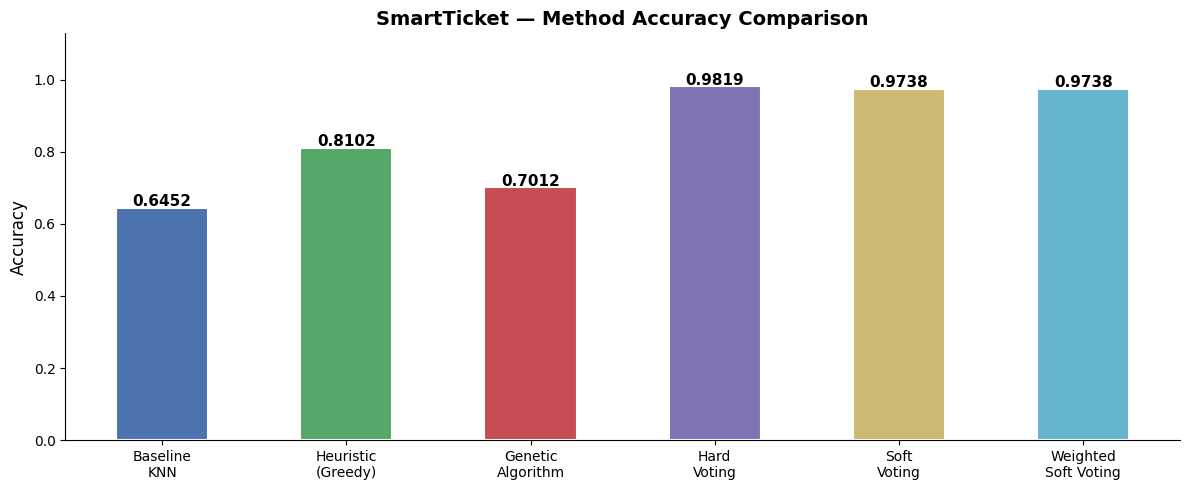

Saved comparison_chart.png


In [28]:
# Comparison chart
methods = [
    "Baseline\nKNN", "Heuristic\n(Greedy)", "Genetic\nAlgorithm",
    "Hard\nVoting", "Soft\nVoting", "Weighted\nSoft Voting",
]
accuracies = [baseline_acc, heuristic_score, ga_score, hard_acc, soft_acc, weighted_acc]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(methods, accuracies, color=colors, width=0.5, edgecolor="white", linewidth=1.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{acc:.4f}", ha="center", fontweight="bold", fontsize=11)
ax.set_ylim(0, max(accuracies) * 1.15)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("SmartTicket — Method Accuracy Comparison", fontsize=14, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "comparison_chart.png"), dpi=150)
plt.show()
print("Saved comparison_chart.png")

In [ ]:
print("""
Feature Selection & Ensemble Strategies — Technical Note
=========================================================

Heuristic (Greedy Forward):
  Adds one feature at a time, picking whichever gives the best
  accuracy boost. Deterministic and fast. May miss interactions.

Genetic Algorithm:
  Searches over entire feature subsets using selection, crossover,
  and mutation. Stochastic. Slower but can find better combinations.

Voting Ensemble (Hard / Soft / Weighted Soft):
  Combines KNN, Decision Tree, Random Forest, Logistic Regression,
  and SVM. Hard voting uses majority vote; soft voting averages
  predicted probabilities; weighted soft voting scales each model
  by its individual accuracy.

Stacking Ensemble:
  Trains a meta-learner (Logistic Regression) on the out-of-fold
  predictions of the base estimators via 5-fold cross-validation.
  Unlike voting, the meta-learner LEARNS the optimal combination
  weights from the data rather than using a fixed rule.
""")

---
## Section 13 — Stacking Ensemble (Week 6)

**Stacking** (stacked generalisation) trains a *meta-learner* on the out-of-fold predictions of the base estimators.  
Unlike voting (which uses a fixed aggregation rule), the meta-learner **learns** from the data how to optimally weight and combine the base classifiers.

- **Level-0 base estimators:** KNN, Decision Tree, Random Forest, SVM  
- **Level-1 meta-learner:** Logistic Regression trained on 5-fold cross-validated out-of-fold predictions  
- **`stack_method="predict_proba"`** — base estimators pass class probabilities to the meta-learner, giving it richer signal than hard labels

In [ ]:
print("=" * 60)
print("  STACKING ENSEMBLE: Meta-Learner Classification")
print("=" * 60)

# Level-0 base estimators
stacking_base = [
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("DecisionTree", DecisionTreeClassifier(random_state=42, max_depth=15)),
    ("RandomForest", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ("SVM", SVC(kernel="rbf", probability=True, random_state=42)),
]

# Level-1 meta-learner
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=stacking_base,
    final_estimator=meta_learner,
    cv=5,                          # 5-fold CV to generate out-of-fold meta-features
    stack_method="predict_proba",  # pass probabilities to meta-learner
    n_jobs=-1,
    passthrough=False,             # meta-learner only sees base predictions
)

print("Training stacking ensemble (5-fold CV for meta-features)...")
stacking_clf.fit(X_train, y_train)
stacking_preds = stacking_clf.predict(X_val)
stacking_acc = accuracy_score(y_val, stacking_preds)

print(f"\nStacking Ensemble Accuracy: {stacking_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, stacking_preds, target_names=le_dept.classes_))

---
## Section 14 — Full Method Comparison (Updated)

Side-by-side comparison of all methods including the stacking ensemble.

In [ ]:
print("=" * 60)
print("  FULL COMPARISON: All Methods")
print("=" * 60)
print(f"{'Method':<32} {'Accuracy':<15} {'# Features'}")
print("-" * 67)
print(f"{'Baseline KNN (all+TF-IDF)':<32} {baseline_acc:<15.4f} {X_train.shape[1]}")
print(f"{'Heuristic (Greedy)':<32} {heuristic_score:<15.4f} {sum(heuristic_mask)}")
print(f"{'Genetic Algorithm':<32} {ga_score:<15.4f} {sum(ga_mask)}")
print(f"{'Hard Voting Ensemble':<32} {hard_acc:<15.4f} {X_train.shape[1]}")
print(f"{'Soft Voting Ensemble':<32} {soft_acc:<15.4f} {X_train.shape[1]}")
print(f"{'Weighted Soft Voting':<32} {weighted_acc:<15.4f} {X_train.shape[1]}")
print(f"{'Stacking Ensemble':<32} {stacking_acc:<15.4f} {X_train.shape[1]}")

best_acc = max(baseline_acc, hard_acc, soft_acc, weighted_acc, stacking_acc)
print(f"\nBest ensemble accuracy    : {best_acc:.4f}")
print(f"Improvement over baseline : +{(best_acc - baseline_acc)*100:.2f} percentage points")

# Updated comparison chart
methods = [
    "Baseline\nKNN", "Heuristic\n(Greedy)", "Genetic\nAlgorithm",
    "Hard\nVoting", "Soft\nVoting", "Weighted\nSoft", "Stacking\nEnsemble",
]
accuracies = [baseline_acc, heuristic_score, ga_score, hard_acc, soft_acc, weighted_acc, stacking_acc]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD", "#E07B54"]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(methods, accuracies, color=colors, width=0.55, edgecolor="white", linewidth=1.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{acc:.4f}", ha="center", fontweight="bold", fontsize=10)
ax.set_ylim(0, max(accuracies) * 1.15)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("SmartTicket — Full Method Accuracy Comparison (Weeks 4, 6, 8)", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "comparison_chart_full.png"), dpi=150)
plt.show()
print("Saved comparison_chart_full.png")

---
## Section 15 — Explainability & Reasoning Layer (Week 8)

A **logic-based assistant** that integrates with the ML predictions via a neuro-symbolic pipeline:

```
ML Prediction ──► Logic Layer (TicketExplainer) ──► Explained Final Decision
                        ▲
               Symbolic Rule Set
               (dept rules · priority rules · override rules)
```

### How logic improves interpretability and control

| Property | Pure ML | ML + Logic Layer |
|---|---|---|
| **Transparency** | Black box — no explanation | Full reasoning trace per ticket |
| **Control** | Needs retraining to fix failures | Edit a rule in minutes |
| **Override** | N/A | High-confidence rules (≥ 90%) override ML |
| **Safety net** | Silent misclassification | Flags ML vs logic disagreements for review |
| **Confidence** | Model probability only | Boosted when ML and logic agree |

### Rule types
- **Department rules** (6) — keyword patterns that indicate a department (e.g., "charged twice" → billing)
- **Priority rules** (4) — patterns that signal urgency level (e.g., "ASAP", "hacked" → urgent)
- **Override rules** (5) — high-confidence domain rules that fire before ML comparison and can force dept + priority (e.g., security breach → account + urgent)

In [ ]:
print("=" * 60)
print("  EXPLAINABILITY: Interpretability Report")
print("=" * 60)

explainer = TicketExplainer(override_threshold=0.90, review_on_disagreement=True)
explainer.print_interpretability_report()

In [ ]:
print("=" * 60)
print("  EXPLAINABILITY: Symbolic Rule Catalogue")
print("=" * 60)

# Print all rules in the knowledge base
print_rule_catalogue()

### 15.2 — Example Explanations

Five representative tickets showing how the logic layer explains and (where appropriate) overrides the ML prediction.

In [ ]:
# Instantiate the explainer (self-contained so this cell can run standalone)
explainer = TicketExplainer(override_threshold=0.90, review_on_disagreement=True)

EXAMPLES = [
    {
        "label": "Billing — correct ML, logic confirms",
        "text": "I was charged twice for order #45231. The duplicate charge of $49.99 appeared on my credit card. Please refund ASAP.",
        "ml_department": "billing",
        "ml_priority": "medium",
        "metadata": {},
    },
    {
        "label": "Security breach — ML wrong, logic overrides to account+urgent",
        "text": "My account has been hacked! Someone changed my email and I can't log in anymore. This is urgent please help immediately!",
        "ml_department": "technical",   # intentionally wrong prediction
        "ml_priority": "medium",
        "metadata": {},
    },
    {
        "label": "Escalated ticket — metadata override raises priority",
        "text": "The app keeps crashing on my iPhone with error code ERR-5432. Tried reinstalling three times.",
        "ml_department": "technical",
        "ml_priority": "low",
        "metadata": {"escalated": 1},  # escalation flag forces high priority
    },
    {
        "label": "Lost package — override to shipping+high",
        "text": "My order #90123 shows delivered but I never received it. Checked with neighbors. Package is missing.",
        "ml_department": "shipping",
        "ml_priority": "medium",
        "metadata": {"num_replies": 6},  # high reply count also escalates
    },
    {
        "label": "General inquiry — low urgency, no override needed",
        "text": "Hi, just wondering if you offer gift wrapping? Also do you ship to Australia? Thanks!",
        "ml_department": "general",
        "ml_priority": "low",
        "metadata": {},
    },
]

for i, ex in enumerate(EXAMPLES, 1):
    print(f"\n{'='*60}")
    print(f"  Example {i}: {ex['label']}")
    print(f"{'='*60}")
    print(f"  Text   : {ex['text'][:90]}...")
    print(f"  ML pred: dept={ex['ml_department']}, priority={ex['ml_priority']}")
    if ex["metadata"]:
        print(f"  Metadata: {ex['metadata']}")
    print()

    result = explainer.explain(
        text=ex["text"],
        ml_department=ex["ml_department"],
        ml_priority=ex["ml_priority"],
        metadata=ex["metadata"],
    )

    print(result.summary())
    print()
    print("  Reasoning trace:")
    for step in result.reasoning_trace:
        print(f"    {step}")

### 15.3 — Batch Explainability on Validation Set

Run the logic layer over the first 50 validation tickets and produce a summary statistics report.

In [ ]:
print("=" * 60)
print("  BATCH EXPLAINABILITY: Validation Set Sample (n=50)")
print("=" * 60)

# Instantiate the explainer (self-contained so this cell can run standalone)
explainer = TicketExplainer(override_threshold=0.90, review_on_disagreement=True)

# Get raw texts aligned with validation indices
val_df = df.iloc[int(len(df) * 0.8):]
sample_n = min(50, len(val_df))
sample_texts = val_df["ticket_text"].fillna("no description provided").tolist()[:sample_n]
sample_ml_depts = [le_dept.inverse_transform([y_val[i]])[0] for i in range(sample_n)]
# Use a placeholder priority (real priority prediction would come from a priority-trained model)
sample_ml_prios = ["medium"] * sample_n

batch_results = explainer.explain_batch(
    texts=sample_texts,
    ml_departments=sample_ml_depts,
    ml_priorities=sample_ml_prios,
)

print(explainer.generate_batch_report(batch_results))

print("\n" + "=" * 60)
print("  Pipeline Complete! (Weeks 4 + 6 + 8)")
print("=" * 60)